# Prediction-pool locus superset pilot

## TL;DR

El filtro agregado local no es un superset de la unión de los locus exactos. Este notebook carga las adquisiciones persistentes del piloto, reproduce las tres políticas y documenta la recomendación sin modificar el pool principal.

## Context & Methods

La adquisición ADQL aplica la *acquisition envelope* global y la calidad relaxed. Después, el código operacional actual construye un locus local con el punto medio de las pendientes e interceptos exactos y el umbral máximo, y conserva filas con menos de dos planos outlier. El piloto compara ese resultado con cada uno de los ocho locus exactos, sus condiciones fotométricas/astrométricas y la alternativa sin locus local.

Las cinco cajas se eligieron antes de consultar: centro galáctico de alta extinción, plano interior alrededor de l≈30°, Cygnus alrededor de l≈80°, anticentro alrededor de l≈180° y una región de alta latitud y menor densidad que solapa un CSV histórico.

In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, display

RUN_ID = 'pilot_20260721_locus_union_v1'
REPORT_DIR = Path('../reports/analysis/prediction_pool_locus_pilot') / RUN_ID
DATA_DIR = Path('../data/processed/prediction_pool_locus_pilot') / RUN_ID
manifest = json.loads((REPORT_DIR / 'manifest.json').read_text(encoding='utf-8'))
assert manifest['status'] == 'completed'
print(f"Run: {RUN_ID} | completed: {manifest['completed_at']}")

Run: pilot_20260721_locus_union_v1 | completed: 2026-07-22T03:29:50.264398+00:00


## Data

Cada consulta nueva conserva ADQL, CSV, Gaia job id y SHA-256 en el manifiesto. La tabla de fuentes incluye el resultado agregado, cada locus exacto, calidad y astrometría por variante, disponibilidad de feature sets y número de locus/variantes que aceptan cada fuente.

In [2]:
table_names = [
    'headline_metrics', 'region_summary', 'variant_summary', 'magnitude_summary',
    'feature_availability', 'known_wr_summary', 'known_wr_affected',
    'plane_discrepancy_summary', 'current_pool_reconciliation',
    'legacy_lineage_summary', 'boundary_samples',
]
tables = {name: pd.read_csv(REPORT_DIR / f'{name}.csv') for name in table_names}
sources = pd.read_parquet(DATA_DIR / 'source_comparison.parquet')
controls = pd.read_parquet(DATA_DIR / 'known_wr_controls.parquet')
print(f"Acquired sources: {len(sources):,} | WR controls: {len(controls):,}")
display(tables['region_summary'])

Acquired sources: 9,102 | WR controls: 347


,region,area_deg2,acquisition_rows,acquisition_density_per_deg2,aggregated_keep,any_exact_locus_keep,any_exact_variant_keep,exact_locus_not_aggregate,exact_locus_not_aggregate_pct_acquisition,exact_locus_not_aggregate_pct_exact_union,exact_variant_not_aggregate,exact_variant_not_aggregate_pct_acquisition,exact_variant_not_aggregate_pct_exact_union,aggregate_not_exact,aggregate_not_exact_variant,exact_variant_union_growth_over_aggregate,acquisition_growth_over_aggregate
0,galactic_center_extinction,0.107207,21,195.883033,8,9,9,1,0.047619,0.111111,1,0.047619,0.111111,0,0,0.125000,1.625000
1,inner_plane_l30,0.249739,1270,5085.308555,721,875,871,154,0.121260,0.176000,150,0.118110,0.172216,0,0,0.208044,0.761442
2,cygnus_l80,0.187588,936,4989.669602,651,691,691,44,0.047009,0.063676,44,0.047009,0.063676,4,4,0.061444,0.437788
3,anticenter_l180,0.875148,6561,7497.016894,4280,4384,4378,128,0.019509,0.029197,126,0.019204,0.028780,24,28,0.022897,0.532944
4,legacy_high_latitude,0.461743,314,680.032330,198,202,202,6,0.019108,0.029703,6,0.019108,0.029703,2,2,0.020202,0.585859


## Results

### Comparación de las tres políticas

La comparación primaria es `passes_any_exact_locus & ~aggregated_locus_keep`. Para la decisión operacional se usa `passes_any_exact_variant`, que además exige calidad y astrometría compatibles con alguna variante.

In [3]:
headline = tables['headline_metrics'].iloc[0]
summary = pd.DataFrame({
    'policy': ['Current aggregate', 'Compatible exact union', 'Acquisition envelope only'],
    'sources': [
        headline.current_aggregate_keep,
        headline.compatible_exact_union_keep,
        headline.acquisition_sources,
    ],
})
display(summary)
print(f"Geometric exact/not aggregate: {int(headline.geometric_exact_not_aggregate):,}")
print(f"Compatible additions: {int(headline.compatible_exact_not_aggregate):,}")
print(f"Net exact-union growth: {headline.net_exact_union_growth:.2%}")
print(f"Envelope-only growth: {headline.envelope_growth:.2%}")

,policy,sources
0,Current aggregate,5858.0
1,Compatible exact union,6151.0
2,Acquisition envelope only,9102.0


Geometric exact/not aggregate: 333
Compatible additions: 327
Net exact-union growth: 5.00%
Envelope-only growth: 55.38%


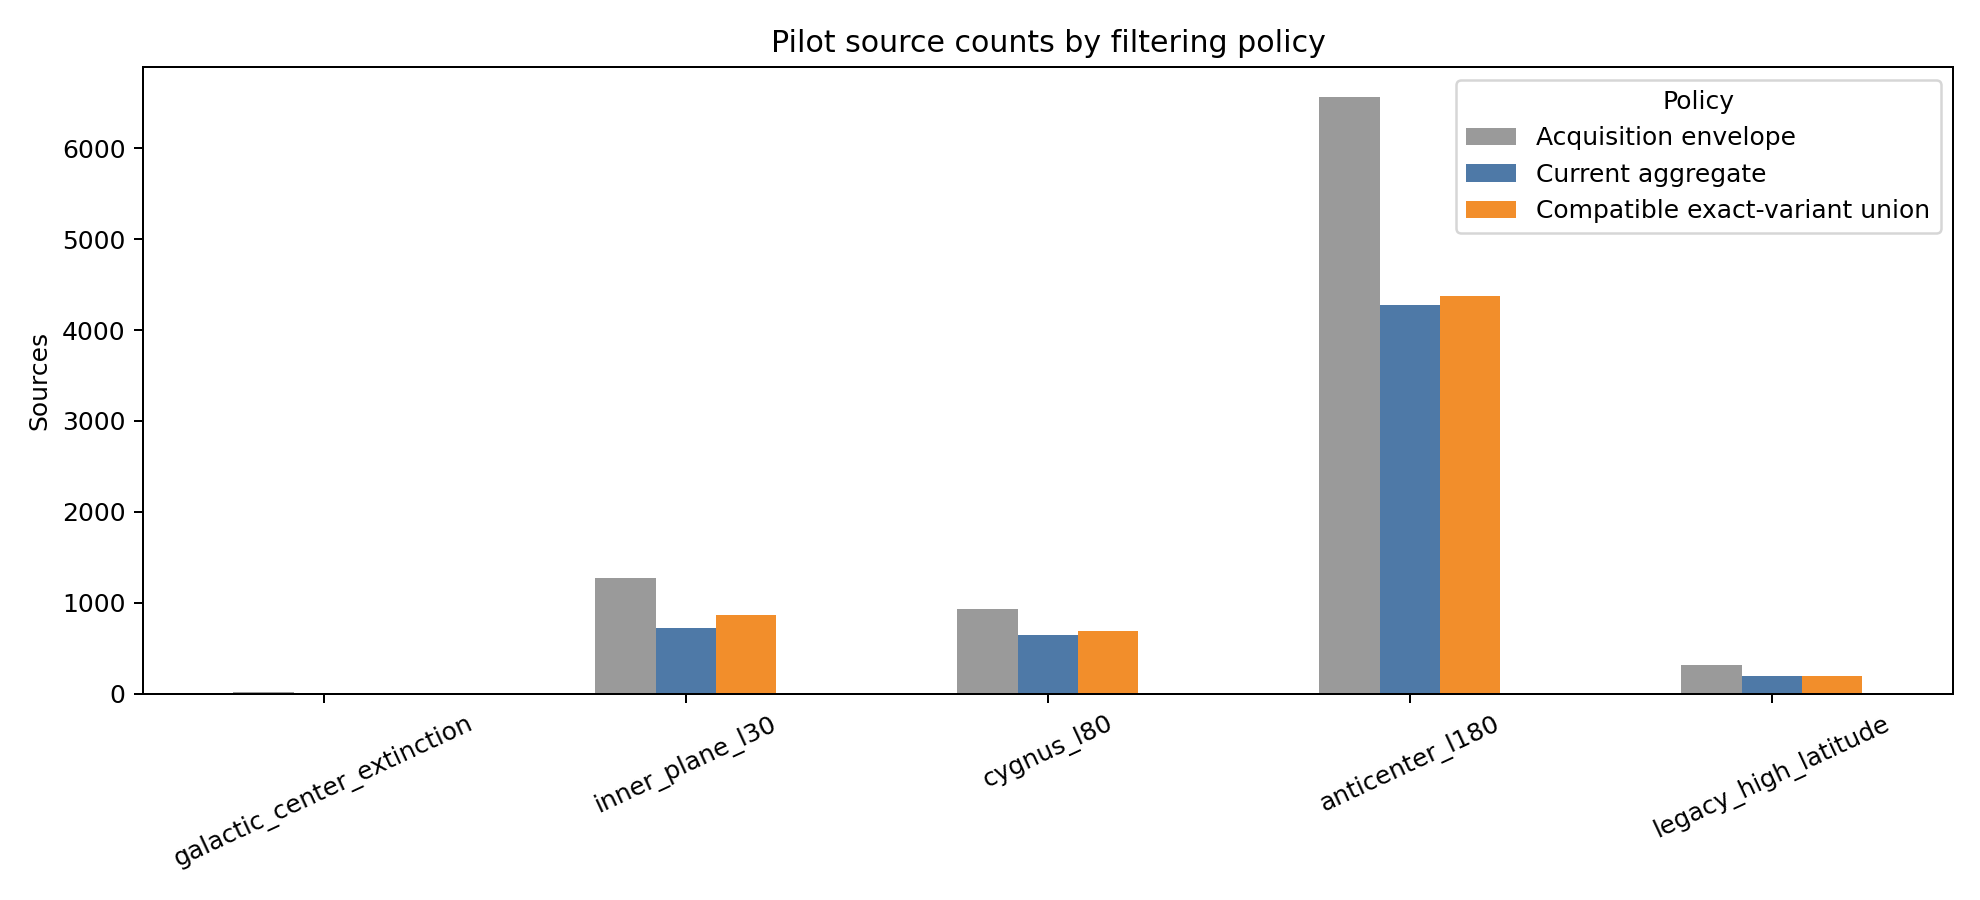

In [4]:
display(Image(filename=REPORT_DIR / 'policy_counts_by_region.png'))

### Resultados por variante, magnitud y densidad

El efecto no es uniforme. Las variantes fotométricas y `parallax_soft` son las más expuestas; los cortes `poe_2` y `poe_3` reducen mucho el número de discrepancias compatibles.

,variant,exact_variant_keep,exact_variant_not_aggregate,exact_variant_not_aggregate_pct
0,strict_photometry,4767,215,0.045102
5,relaxed_parallax_soft,5601,235,0.041957
1,strict_parallax_soft,4515,178,0.039424
4,relaxed_photometry,5667,97,0.017117
3,strict_poe_3,3070,10,0.003257
2,strict_poe_2,3295,5,0.001517
7,relaxed_poe_3,3052,2,0.000655
6,relaxed_poe_2,3494,0,0.000000


,feature_set,available_rows,available_pct
0,colors_parallax,8935,0.981652
1,colors_parallax_error,8935,0.981652


,region,acquisition_density_per_deg2,exact_variant_not_aggregate,exact_variant_not_aggregate_pct_exact_union
3,anticenter_l180,7497.016894,126,0.028780
1,inner_plane_l30,5085.308555,150,0.172216
2,cygnus_l80,4989.669602,44,0.063676
4,legacy_high_latitude,680.032330,6,0.029703
0,galactic_center_extinction,195.883033,1,0.111111


,region,magnitude_bin,acquisition_rows,aggregated_keep,any_exact_locus_keep,any_exact_variant_keep,exact_locus_not_aggregate,exact_variant_not_aggregate,exact_locus_not_aggregate_pct,exact_variant_not_aggregate_pct,exact_locus_not_aggregate_pct_exact_union,exact_variant_not_aggregate_pct_exact_union
0,anticenter_l180,G<12,70,36,37,37,1,1,0.014286,0.014286,0.027027,0.027027
1,anticenter_l180,12<=G<14,376,257,261,261,7,7,0.018617,0.018617,0.026820,0.026820
2,anticenter_l180,14<=G<16,1426,980,1002,1002,34,34,0.023843,0.023843,0.033932,0.033932
3,anticenter_l180,16<=G<18,3308,2123,2186,2183,72,70,0.021765,0.021161,0.032937,0.032066
4,anticenter_l180,G>=18,1381,884,898,895,14,14,0.010138,0.010138,0.015590,0.015642
5,cygnus_l80,G<12,12,5,4,4,0,0,0.000000,0.000000,0.000000,0.000000
6,cygnus_l80,12<=G<14,31,27,26,26,0,0,0.000000,0.000000,0.000000,0.000000
7,cygnus_l80,14<=G<16,95,72,74,74,3,3,0.031579,0.031579,0.040541,0.040541
8,cygnus_l80,16<=G<18,199,141,152,152,11,11,0.055276,0.055276,0.072368,0.072368
9,cygnus_l80,G>=18,599,406,435,435,30,30,0.050083,0.050083,0.068966,0.068966


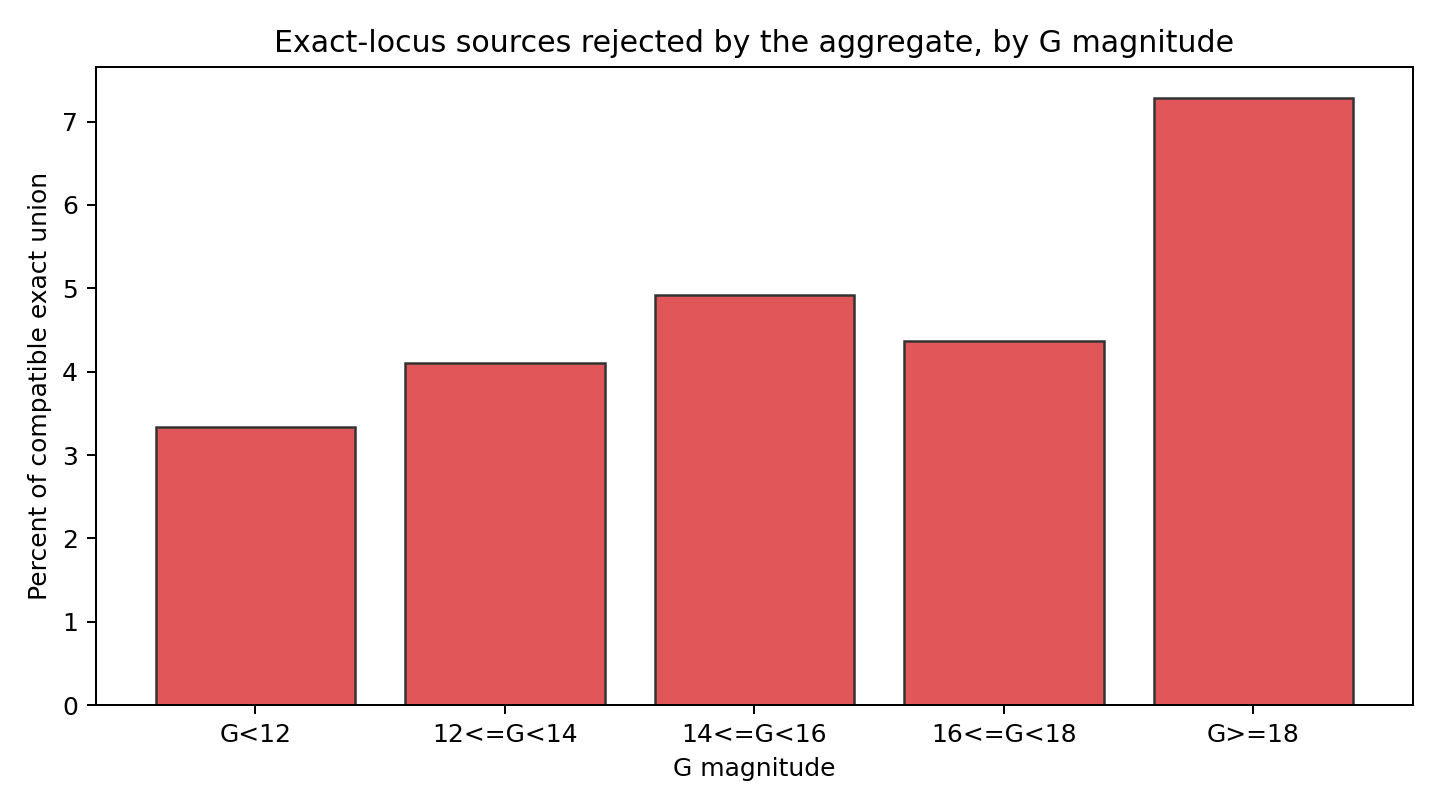

In [5]:
display(tables['variant_summary'].sort_values('exact_variant_not_aggregate_pct', ascending=False))
display(tables['feature_availability'])
density_cols = [
    'region', 'acquisition_density_per_deg2', 'exact_variant_not_aggregate',
    'exact_variant_not_aggregate_pct_exact_union',
]
display(tables['region_summary'][density_cols].sort_values('acquisition_density_per_deg2', ascending=False))
display(tables['magnitude_summary'])
display(Image(filename=REPORT_DIR / 'discrepancy_rate_by_magnitude.png'))

### Geometría de la discrepancia

Los dos planos 2MASS que comparten `H_K` explican casi todos los rechazos agregados. Las líneas gruesas/segmentadas representan el centro y las fronteras del agregado; las líneas finas y punteadas muestran centros y fronteras exactas. Los puntos rojos pasan al menos un locus exacto pero fallan el agregado.

,plane,discrepancy_rows,aggregate_outlier_rows,aggregate_outlier_pct,inside_at_least_one_exact_band
0,J_H__H_K,333,328,0.984985,313
1,J_K__H_K,333,326,0.978979,23
2,G_BP__G_RP,333,5,0.015015,5
3,G_RP__BP_RP,333,4,0.012012,2
4,G_BP__BP_RP,333,3,0.009009,3
5,J_H__J_K,333,3,0.009009,3


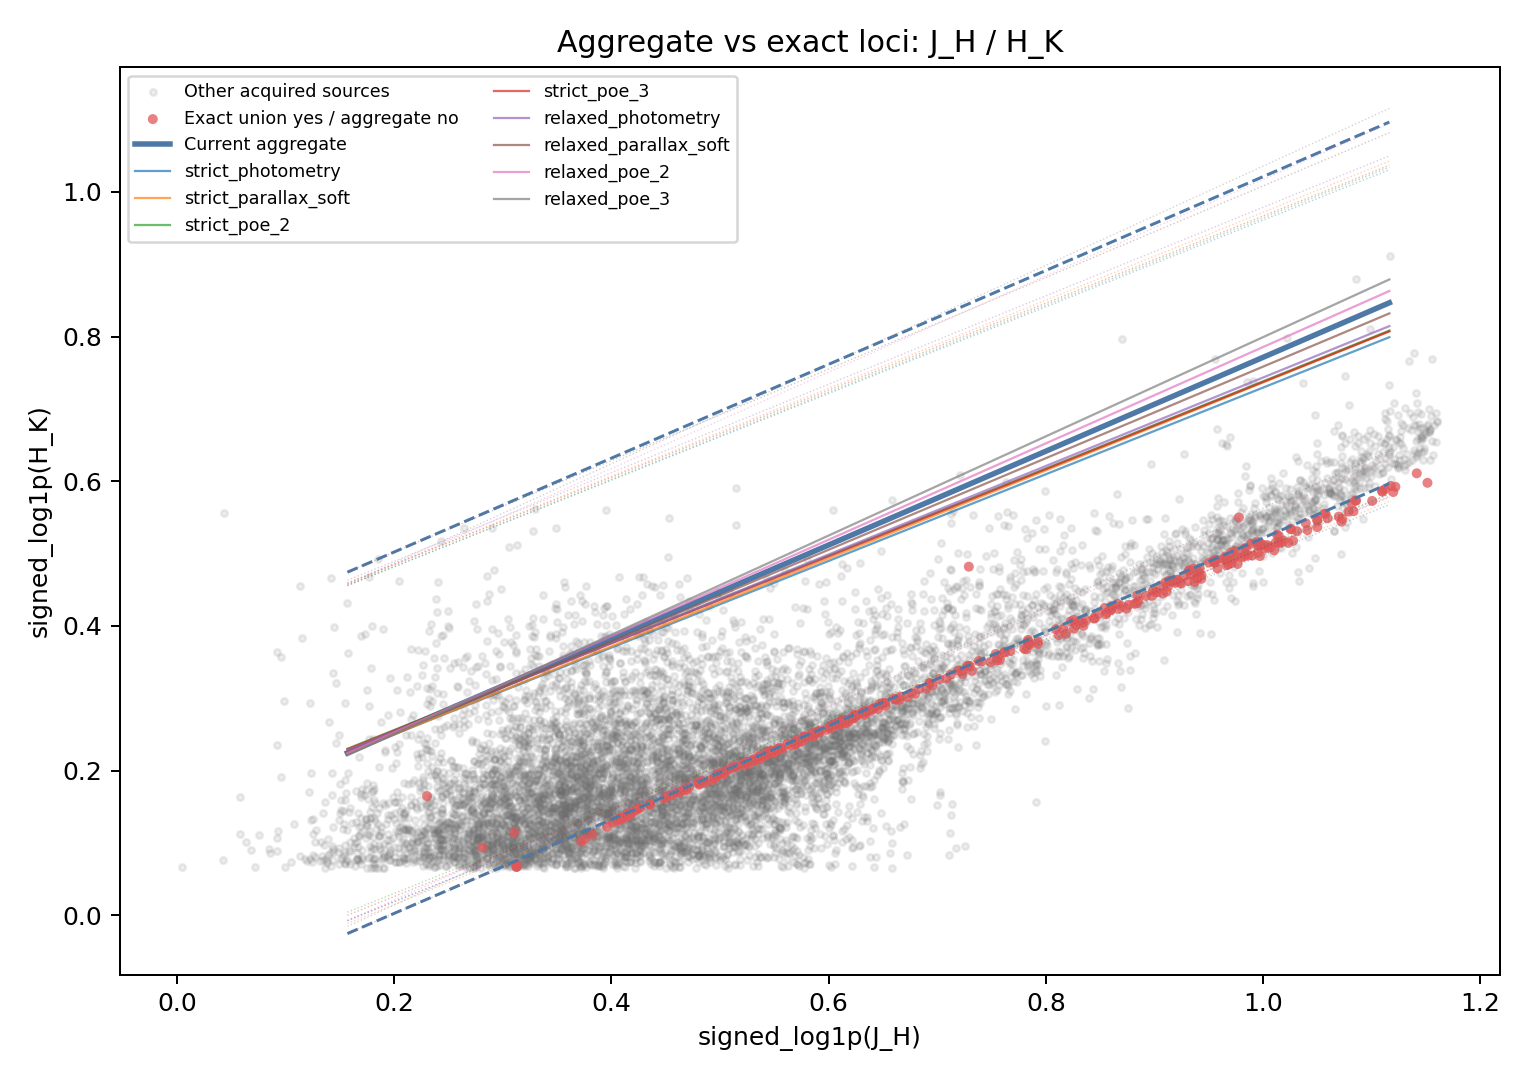

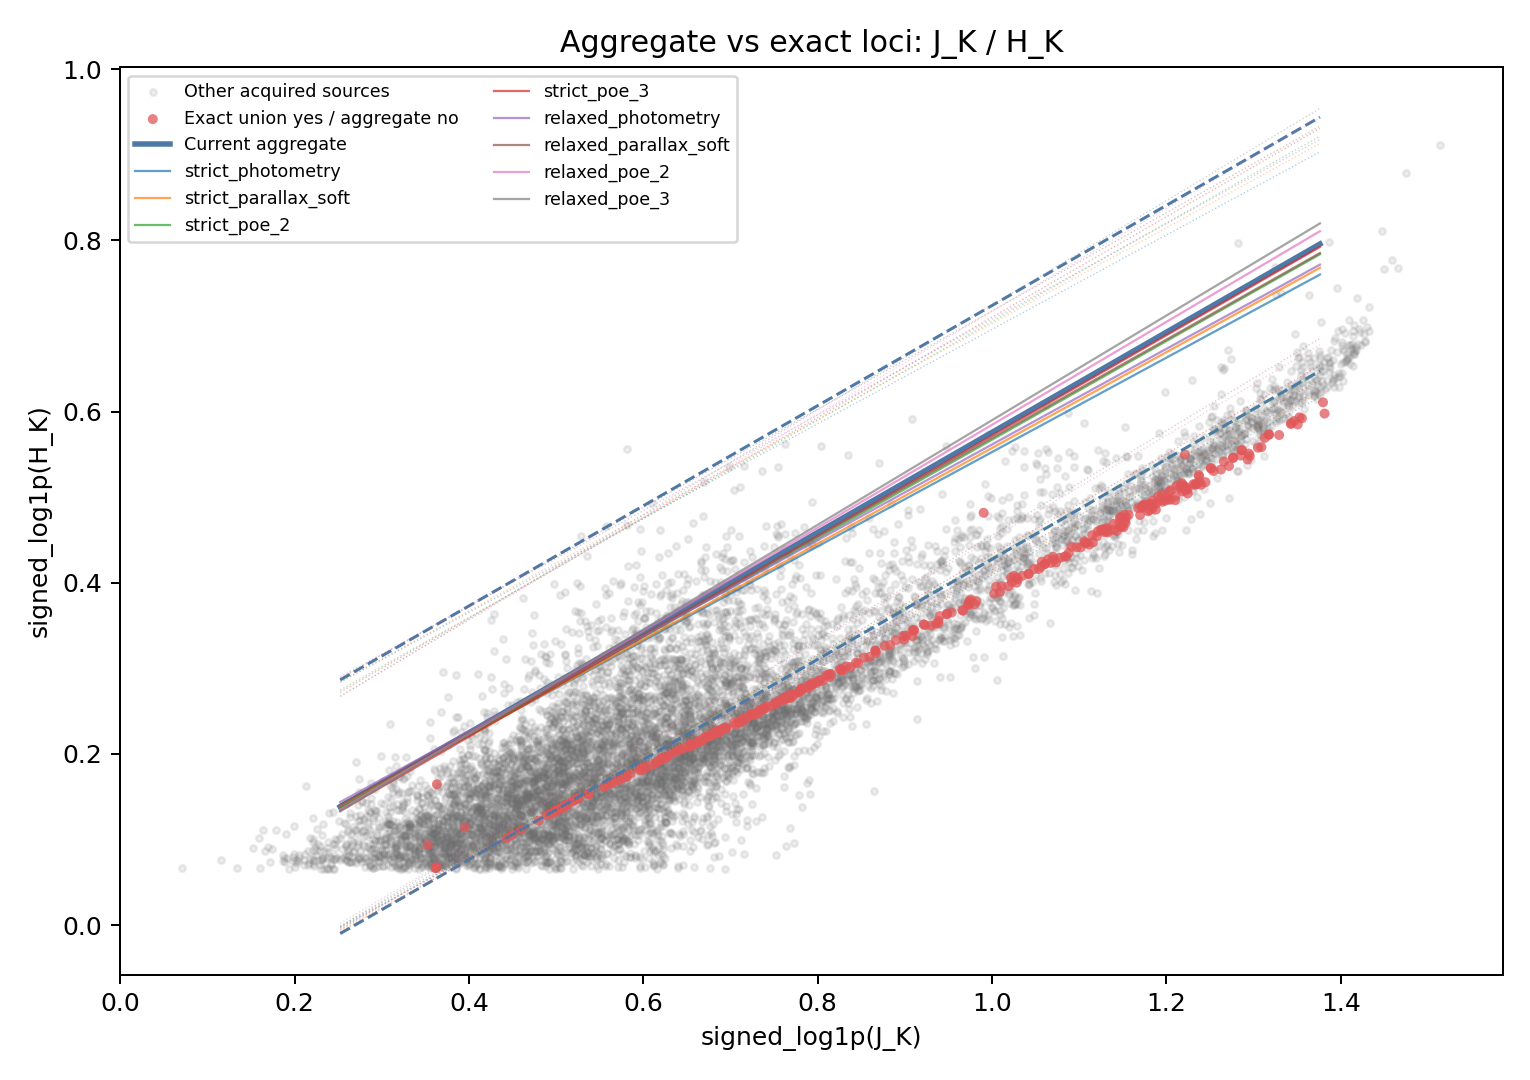

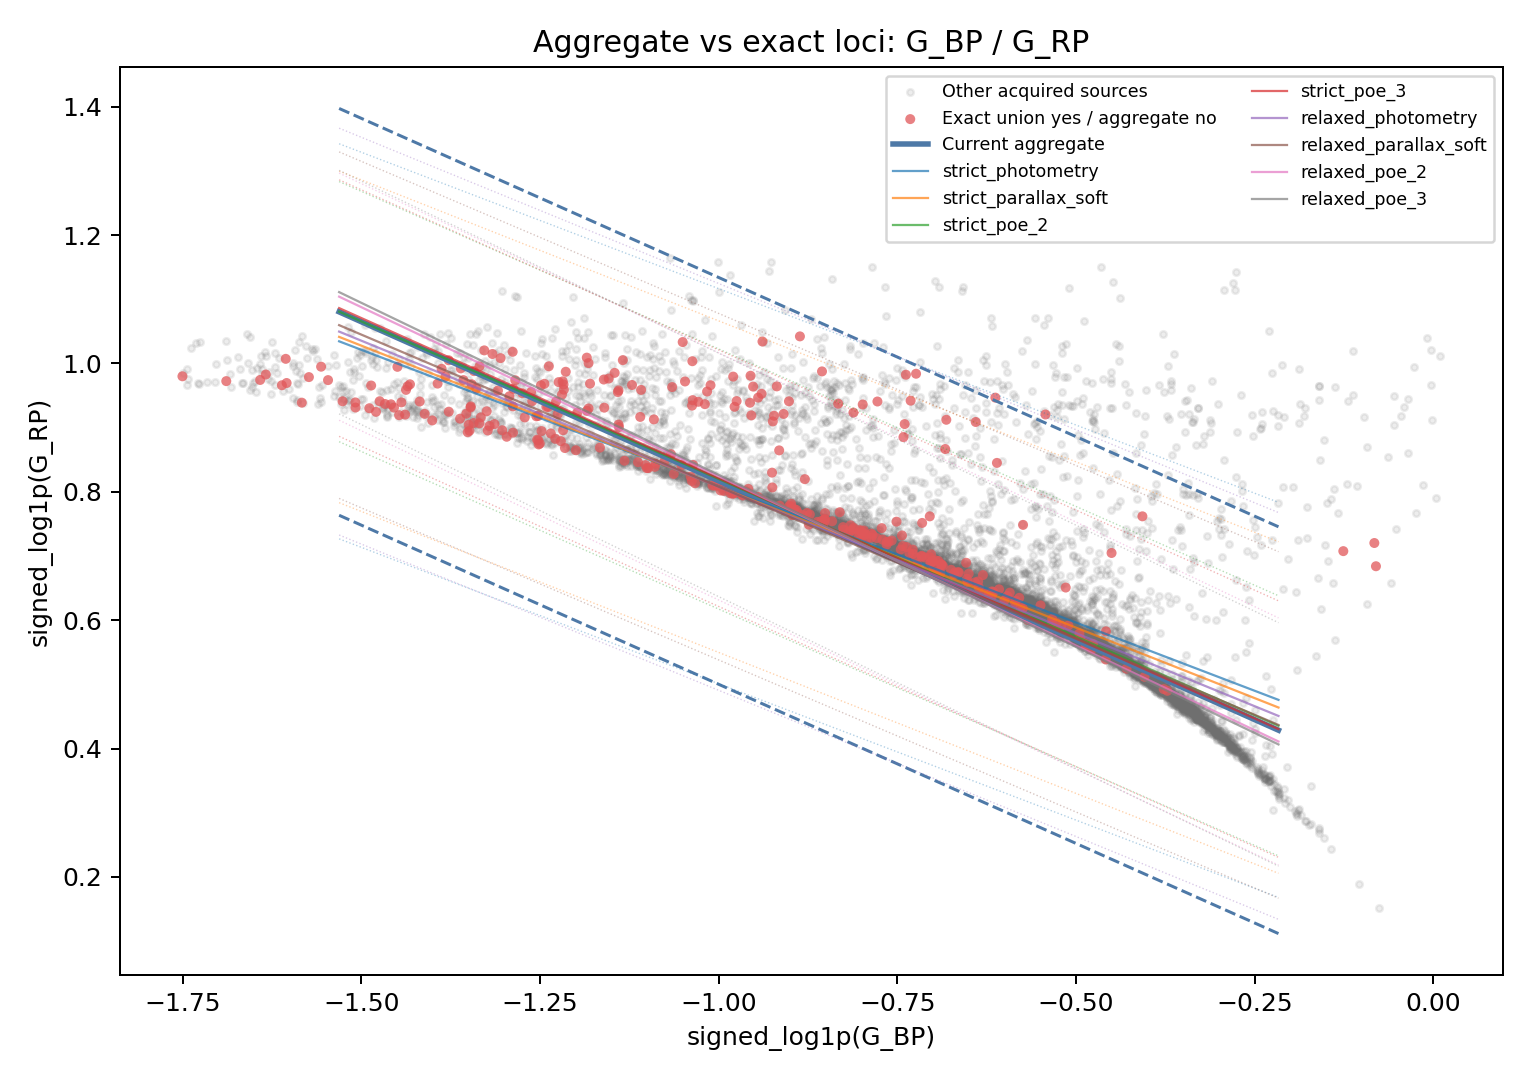

In [6]:
display(tables['plane_discrepancy_summary'])
for filename in [
    'plane_discrepancy__J_H__H_K.png',
    'plane_discrepancy__J_K__H_K.png',
    'plane_discrepancy__G_BP__G_RP.png',
]:
    display(Image(filename=REPORT_DIR / filename))

### Controles WR y reconciliación con el pool actual

La unión exacta recupera dos controles que el agregado rechaza. La reconciliación de `source_id` confirma que el piloto reproduce el filtro local vigente: ninguna fuente del pool actual queda fuera de la reconstrucción agregada; las pocas filas agregadas adicionales se eliminan en el paso posterior de exclusión de fuentes conocidas.

In [7]:
display(tables['known_wr_summary'])
display(tables['known_wr_affected'])
display(tables['current_pool_reconciliation'])

,known_wr_controls,within_acquisition_envelope,outside_acquisition_envelope,current_policy_keep,exact_union_policy_keep,exact_union_not_current
0,347,343,4,332,334,2


,source_id,wr_id,Spectral Type,G,BP_RP,J_K,W1_W2,aggregated_outlier_plane_count,exact_loci_accept_count,exact_variants_accept_count
0,4306688266055108480,122-15,WN6,18.465390,5.145134,2.059,-0.096,2,2,2
1,2013906561629759232,157,WN5o(+B1II),10.346903,1.096946,0.491,0.078,3,1,1


,region,pilot_aggregate_keep,current_pool_rows,current_pool_not_pilot_aggregate,pilot_aggregate_not_current_pool
0,galactic_center_extinction,8,7,0,1
1,inner_plane_l30,721,720,0,1
2,cygnus_l80,651,649,0,2
3,anticenter_l180,4280,4278,0,2
4,legacy_high_latitude,198,198,0,0


### Linaje de los CSV parciales

Los CSV históricos sirven como control auxiliar de estabilidad de Gaia, pero no como evidencia primaria: su registro parcial conserva tesela, job y fecha, pero no texto/hash ADQL ni hashes de configuración, envelope o locus.

In [8]:
display(tables['legacy_lineage_summary'])
legacy = next(r['legacy_comparison'] for r in manifest['regions'] if 'legacy_comparison' in r)
display(pd.DataFrame([legacy]))

,csv_count,csv_bytes,partial_registry_matches,partial_completed_matches,partial_registry_orphan_count,partial_registry_orphans,main_registry_matches,config_hash_available,acquisition_envelope_hash_available,exact_locus_hash_available,query_text_or_hash_available,primary_analysis_eligible,reason
0,386,2504583862,385,385,1,test_simple,0,False,False,False,False,False,Tile/job/timestamp lineage exists for 385 CSVs...


,jaccard,legacy_csv_path,legacy_csv_sha256,legacy_subset_rows,legacy_tile_registry,lineage_status,new_rows,source_id_intersection,source_id_union
0,1.0,E:\Proyectos\Wolf-Rayet-Detector\data\raw\pred...,76094fb39539284e901e695f26af75c6700a1640a77e6c...,314,"[completed, 4910, E:\Proyectos\Wolf-Rayet-Dete...",insufficient_for_primary_analysis,314,314,314


## Takeaways

1. El agregado actual no conserva la unión exacta y el pool existente no es suficiente para scoring definitivo de todos los modelos previstos.
2. La opción recomendada es mantener el pipeline condicionado al locus y usar la unión lógica de variantes exactas compatibles, con definición versionada y diagnósticos persistidos.
3. Aplicar sólo la acquisition envelope maximiza sensibilidad, pero aumenta el volumen un 55,4% en este piloto. Es una política de respaldo, no la primera recomendación.
4. No se debe extrapolar el +5,0% neto directamente a los 58 millones: las cinco cajas son representativas, no aleatorias. Hace falta una auditoría independiente más amplia antes de reconstruir.
5. El resto del plan (source hash, métricas within-locus, OOF/calibración, sampler none, top-K y Streamlit) permanece posterior a esta decisión.

### Reproducción

```powershell
wr-detector pilot-prediction-pool-locus --config configs/prediction_pool_locus_pilot.yaml
wr-detector pilot-prediction-pool-locus --config configs/prediction_pool_locus_pilot.yaml --skip-download
```